In [ ]:
# Mounts google drive so it can be read and written to by the program
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Commands to get words dataset from my google drive to the local runtime
!mkdir data
!mkdir data/words
!tar -xf /content/drive/MyDrive/IAM_Words/words.tgz -C data/words
!cp /content/drive/MyDrive/IAM_Words/words.txt data

In [ ]:
!head -25 data/words.txt # Display first 25 lines of text so we can visualize it

#--- words.txt ---------------------------------------------------------------#
#
# iam database word information
#
# format: a01-000u-00-00 ok 154 1 408 768 27 51 AT A
#
#     a01-000u-00-00  -> word id for line 00 in form a01-000u
#     ok              -> result of word segmentation
#                            ok: word was correctly
#                            er: segmentation of word can be bad
#
#     154             -> graylevel to binarize the line containing this word
#     1               -> number of components for this word
#     408 768 27 51   -> bounding box around this word in x,y,w,h format
#     AT              -> the grammatical tag for this word, see the
#                        file tagset.txt for an explanation
#     A               -> the transcription for this word
#
a01-000u-00-00 ok 154 408 768 27 51 AT A
a01-000u-00-01 ok 154 507 766 213 48 NN MOVE
a01-000u-00-02 ok 154 796 764 70 50 TO to
a01-000u-00-03 ok 154 919 757 166 78 VB stop
a01-000u-00-04 ok 154 118

In [ ]:
# Imports all libraries and sets random seeds
from tensorflow.keras.layers import StringLookup
from tensorflow import keras
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import os
from contextlib import redirect_stdout
from sklearn.model_selection import train_test_split
np.random.seed(100)
tf.random.set_seed(100)

In [ ]:
# This is code to read each line from the text document shown above in a previous cell
data_path = "data"
words = []

word_lines = open(f"{data_path}/words.txt", "r").readlines()
for line in word_lines:
  # This if statement means it will ignore lines starting with a "#" and continue to the next iteration
  if line[0] == "#":
    continue

  # We also don't include lines marked with an error tag
  if line.split(" ")[1] != "err":
    words.append(line)

In [ ]:

# The data is split in the ratio of percentages 90 : 5 : 5
# We also shuffle data by setting shuffle=True
train_data, test_data = train_test_split(words, shuffle=True,
                                              test_size=0.1, random_state=100)
val_data, test_data = train_test_split(test_data, shuffle=False,
                                              test_size=0.5, random_state=100)

print(f"Total training samples: {len(train_data)}")
print(f"Total validation samples: {len(val_data)}")
print(f"Total test samples: {len(test_data)}")

Total training samples: 86810
Total validation samples: 4823
Total test samples: 4823


In [ ]:

def extract_image_paths_and_labels(samples: list):
  """
    Function takes as parameter the list samples which contains the lines of our
    .txt files that have each image path and their corresponding labels of the
    dataset. It then uses string processing to extract these and return the paths
    and labels as a tuple.
  """
  paths = []
  labels = []
  for (i, file_line) in enumerate(samples):
    line = file_line.split("\n")[0] # This removes the "\n" at the end of each line
    path_split = line.strip().split(" ") # Further cleaning

    # Now we construct the filepath of the image from the format in the text file
    image_name = path_split[0]
    folderI = image_name.split("-")[0]
    folderII = folderI + "-" + image_name.split("-")[1]
    image_path = os.path.join(
        data_path, "words", folderI, folderII, image_name + ".png")
    if os.path.getsize(image_path): # Checks file at image_path isn't empty
      paths.append(image_path)
      labels.append(path_split[-1])


  return paths, labels


train_img_paths, train_labels = extract_image_paths_and_labels(train_data)
val_img_paths, val_labels = extract_image_paths_and_labels(val_data)
test_img_paths, test_labels = extract_image_paths_and_labels(test_data)



In [ ]:
characters = set()
max_len = 0
# We need to find the maximum length of a word so we can construct the shape of the input label for the neural network
# Also having a characters set allows us to store the letters used for the StringLookup objects later on

for label in train_labels:
  for char in label:
    characters.add(char)
  max_len = max(max_len, len(label))

print("Maximum length: ", max_len)
print("Vocab size: ", len(characters))

Maximum length:  21
Vocab size:  78


In [ ]:
# This creates a mapping from character to number so neural network can perform numerical operations on data
# We create num_to_char so we can then decode our neural network's output which will be in numbers
char_to_num = StringLookup(vocabulary=list(characters), mask_token=None)

num_to_char = StringLookup(
    vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
)
print(char_to_num.get_vocabulary())

['[UNK]', "'", 'V', 'k', '1', 'z', ')', 'D', 'g', 'L', 'B', 'J', 'y', ';', 't', 'f', 'w', 'N', 'F', 'x', 'p', 'r', 'E', 'n', 'e', '(', ',', 'i', 'Q', '"', 'S', 'I', 'T', 'K', 'X', 'l', '4', '-', 'A', '*', 's', ':', '&', 'm', '5', '8', '6', 'v', 'M', 'Z', '#', 'H', '2', '?', '0', 'O', 'd', 'b', '!', 'q', '3', 'W', 'j', 'Y', 'c', '+', '7', 'P', 'U', '9', 'o', 'u', '/', 'R', 'h', 'G', '.', 'a', 'C']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
batch_size = 64 # Stops runtime from getting stuck in training as less RAM is needed

image_width = 128
image_height = 32


def preprocess_image(image_path, image_size=(image_width, image_height)):
  # Reads file as tensor
  image = tf.io.read_file(image_path)
  # Grayscales image
  image = tf.image.decode_png(image, 1)

  # Resizes image with pad to keep aspect ratio
  image = tf.image.resize_with_pad(image, image_height, image_width)

  # Standard image processing transformations before neural network training
  image = tf.transpose(image, perm=[1, 0, 2])
  image = tf.image.flip_left_right(image)

  # Normalizes data so every value is between 0 and 1 as this is what model needs
  image = tf.cast(image, tf.float32) / 255.0
  return image


def preprocess_label(label):
  # Turns label into numerical vector with padding where needed
  label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8"))
  length = tf.shape(label)[0]
  pad_amount = max_len - length
  label = tf.pad(label, paddings=[[0, pad_amount]], constant_values=99)
  return label


def preprocess_data(image_path, label):
  # Creates dictionary pair with key and value pairs
  image = preprocess_image(image_path)
  label = preprocess_label(label)

  return {"image":image, "label": label}

def prepare_dataset(image_paths, labels):
  # Creates tensor dataset whilst processing image_paths and labels with map calling preprocess_data function
  dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels)).map(
      preprocess_data, num_parallel_calls=AUTOTUNE
  )
  return dataset.batch(batch_size).cache().prefetch(AUTOTUNE)

In [ ]:
train_ds = prepare_dataset(train_img_paths, train_labels)
validation_ds = prepare_dataset(val_img_paths, val_labels)
test_ds = prepare_dataset(test_img_paths, test_labels)

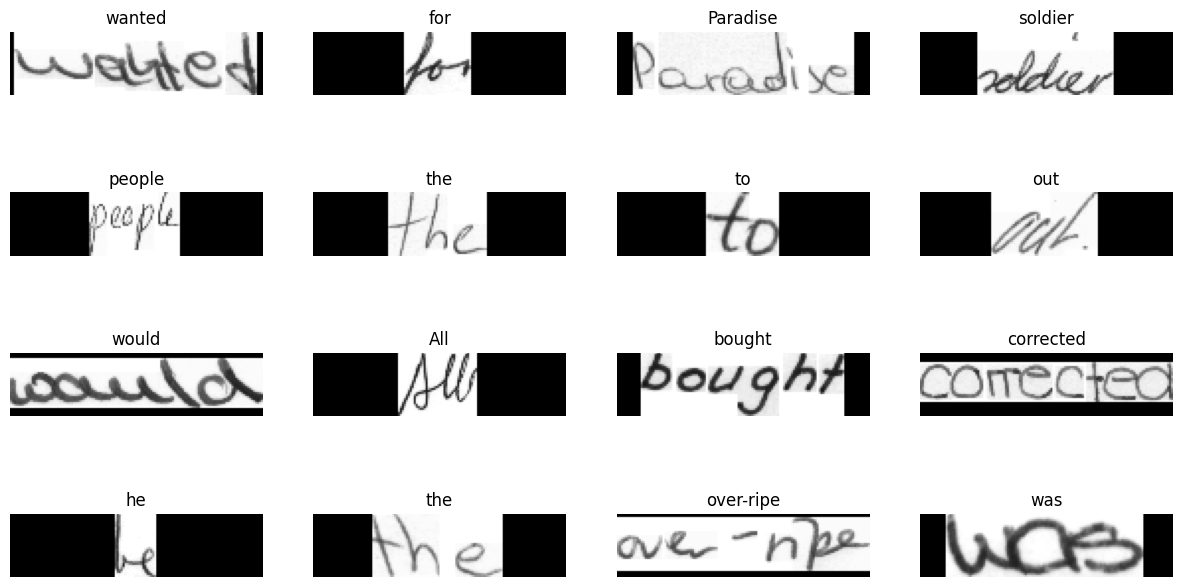

In [ ]:
for data in test_ds.take(1):
  # This is matplotlib code to visualize the image from a test_ds batch
  images, labels = data["image"], data["label"]

  _, ax = plt.subplots(4, 4, figsize=(15, 8))

  for i in range(16):
    # Reverses effect of previous image pre-processing
    img = images[i]
    img = tf.image.flip_left_right(img)
    img = tf.transpose(img, perm=[1, 0, 2])
    img = (img * 255.0).numpy().clip(0, 255).astype(np.uint8)
    img = img[:, :, 0]

    # Decodes vectorized label back to string
    label = labels[i]
    indices = tf.gather(label, tf.where(tf.math.not_equal(label, 99)))

    label = tf.strings.reduce_join(num_to_char(indices))
    label = label.numpy().decode("utf-8")

    # Places image in the 4x4 grid in order
    ax[i // 4, i % 4].imshow(img, cmap="gray")
    ax[i // 4, i % 4].set_title(label)
    ax[i // 4, i % 4].axis("off")

plt.show()

In [ ]:
class CTCLayer(keras.layers.Layer):
  """
    This creates a CTCLayer class that is a customised Keras layer but using
    a ctc_loss function which is useful for the task of handwriting recognition
  """
  def __init__(self, name=None):
    super().__init__(name=name)
    # Defines the loss function
    self.loss_fn = keras.backend.ctc_batch_cost

  def call(self, y_true, y_pred):
    """
      We get the parameters for the loss function and this call function
      adds the CTC loss to the total loss for the backpropagation algorithm
    """
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    loss = self.loss_fn(y_true, y_pred, input_length, label_length)
    self.add_loss(loss)

    return y_pred



In [ ]:
def build_model():
  """
    This function will return our neural network model which is a combination of
    convolutional, dense and recurrent layers.
  """
  # Firstly, we define our input layers
  input_img = keras.Input(shape=(image_width, image_height, 1), name="image")
  labels = keras.layers.Input(name="label", shape=(None,))

  # The next section makes the convolutional, dense and recurrent layers
  x = keras.layers.Conv2D(
      32,
      (3,3),
      activation="relu",
      kernel_initializer="he_normal",
      padding="same",
      name="Conv1",
  )(input_img)
  x = keras.layers.MaxPooling2D((2, 2), name="pool1")(x)

  x = keras.layers.Conv2D(
      64,
      (3,3),
      activation="relu",
      kernel_initializer="he_normal",
      padding="same",
      name="Conv2"
  )(x)
  x = keras.layers.MaxPooling2D((2, 2), name="pool2")(x)

  new_shape = ((image_width // 4), (image_height // 4) * 64)
  x = keras.layers.Reshape(target_shape=new_shape, name="reshape")(x)
  x = keras.layers.Dense(64, activation="relu", name="dense1")(x)
  x = keras.layers.Dropout(0.2)(x)

  x = keras.layers.Bidirectional(
      keras.layers.LSTM(128, return_sequences=True, dropout=0.25)
  )(x)
  x = keras.layers.Bidirectional(
      keras.layers.LSTM(64, return_sequences=True, dropout=0.25)
  )(x)

  x = keras.layers.Dense(
      len(char_to_num.get_vocabulary()) + 2, activation="softmax", name="dense2"
  )(x)

  # Here we define our output layer as an instance of our CTCLayer class from before
  output = CTCLayer(name="ctc_loss")(labels, x)

  model = keras.models.Model(
      inputs=[input_img, labels], outputs=output, name="htr"
  )

  opt = keras.optimizers.Adam()

  model.compile(optimizer=opt)
  return model

model = build_model()
# The function call below allows us to view the structure of our model
model.summary()

Model: "htr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)        │ (None, 128, 32, 1)     │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 128, 32, 32)    │            320 │ image[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 64, 16, 32)     │              0 │ Conv1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv2 (Conv2D)            │ (None, 64, 16, 64)     │         18,496 │ pool1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool2 (MaxPooling2D)      │ (None, 32, 8, 64)      │              0 │ Conv2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 32, 512)        │              0 │ pool2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense1 (Dense)            │ (None, 32, 64)         │         32,832 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 32, 64)         │              0 │ dense1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 32, 256)        │        197,632 │ dropout[0][0]          │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_1           │ (None, 32, 128)        │        164,352 │ bidirectional[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ label (InputLayer)        │ (None, None)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense2 (Dense)            │ (None, 32, 81)         │         10,449 │ bidirectional_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ ctc_loss (CTCLayer)       │ (None, 32, 81)         │              0 │ label[0][0],           │
│                           │                        │                │ dense2[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 424,081 (1.62 MB)

 Trainable params: 424,081 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# We get back our images and labels from the validaton dataset
# This will be used to evaluate our model at the end of each epoch
validation_images = []
validation_labels = []

for batch in validation_ds:
  validation_images.append(batch["image"])
  validation_labels.append(batch["label"])

In [ ]:
def calculate_edit_distance(labels, predictions):
    """
      This function takes paramaters of a list of the ground truth labels and
      the predicted text, which will be generated by the model, and returns
      the mean edit distance between these. Note: edit distance is a string
      metric to quantify how dissimilar two strings are.
    """
    # tf.edit_distance takes SparseTensor objects as arguments
    # Converts labels to sparse tensors.
    saprse_labels = tf.cast(tf.sparse.from_dense(labels), dtype=tf.int64)

    # Decodes models predictions and convert them to sparse tensors.
    input_len = np.ones(predictions.shape[0]) * predictions.shape[1]
    predictions_decoded = keras.backend.ctc_decode(
        predictions, input_length=input_len, greedy=True
    )[0][0][:, :max_len]
    sparse_predictions = tf.cast(
        tf.sparse.from_dense(predictions_decoded), dtype=tf.int64
    )

    # Compute individual edit distances and average them out.
    edit_distances = tf.edit_distance(
        sparse_predictions, saprse_labels, normalize=False
    )
    return tf.reduce_mean(edit_distances)


class EditDistanceCallback(keras.callbacks.Callback):
    """
      Defining a custom callback class - i.e defining what happens at the end
      of each epoch
    """
    def __init__(self, pred_model):
        super().__init__()
        self.prediction_model = pred_model


    def on_epoch_end(self, epoch, logs=None):
        """
          This method calculates the error/edit_distance of the model using
          our validation dataset and also saves the model every 10 epochs.
        """
        edit_distances = []
        # Iterates through validation_images and calculates mean edit_distance of each batch of images
        for i in range(len(validation_images)):
            labels = validation_labels[i]
            predictions = self.prediction_model.predict(validation_images[i])
            edit_distances.append(calculate_edit_distance(labels, predictions).numpy())

        # Displays mean edit_distance after each epoch of training
        print(
            f"Mean edit distance for epoch {epoch + 1}: {np.mean(edit_distances):.4f}"
        )
        # If statement ensures model is only saved every 10 epochs
        if (epoch + 1) % 10 == 0:
            self.prediction_model.save(f'/content/drive/MyDrive/HTR2models/htr2_{epoch + 1}.keras')


In [ ]:

!mkdir /content/drive/MyDrive/HTR2models

mkdir: cannot create directory ‘/content/drive/MyDrive/HTR2models’: File exists


In [ ]:
"""
  This section of code writes the char_to_num mapping onto a .txt file as it's
  needed for decoding the model's future predictions
"""
from contextlib import redirect_stdout

with open('/content/drive/MyDrive/HTR2models/char2num.txt', 'w+') as file:
    with redirect_stdout(file):
        print(char_to_num.get_vocabulary())


In [ ]:
# Here we train our model for 100 epochs
epochs = 100

# We call our previously defined build_model function
model = build_model()
prediction_model = keras.models.Model(
    model.get_layer(name="image").output, model.get_layer(name="dense2").output
)
# Create an instance of our customised callback defined earlier
edit_distance_callback = EditDistanceCallback(prediction_model)

# .fit() will train the model on the training data and returns the history of training
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[edit_distance_callback],
)

Streaming output truncated to the last 5000 lines.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Mean edit distance for epoch 37: 17.5074
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 51s 38ms/step - loss: 126.8871 - val_loss: 143.8893
Epoch 38/100
2/2 ━━━━━━━━━━

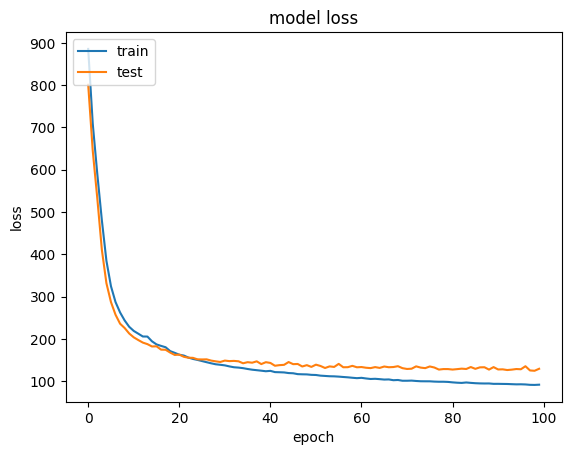

In [ ]:
# Visualizes history of training by plotting the loss for each epoch
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
# The test line is actually the validation dataset but it is standard to call these train and test
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# Save the entire model as a `.keras` zip archive.
prediction_model.save('/content/drive/MyDrive/HTR2models/htr2_model_100epochs.keras')

/content/drive/MyDrive


In [ ]:
# We can load our saved model for inference on the test data
epoch100_model = tf.keras.models.load_model('/content/drive/MyDrive/HTR2models/htr2_100.keras')


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


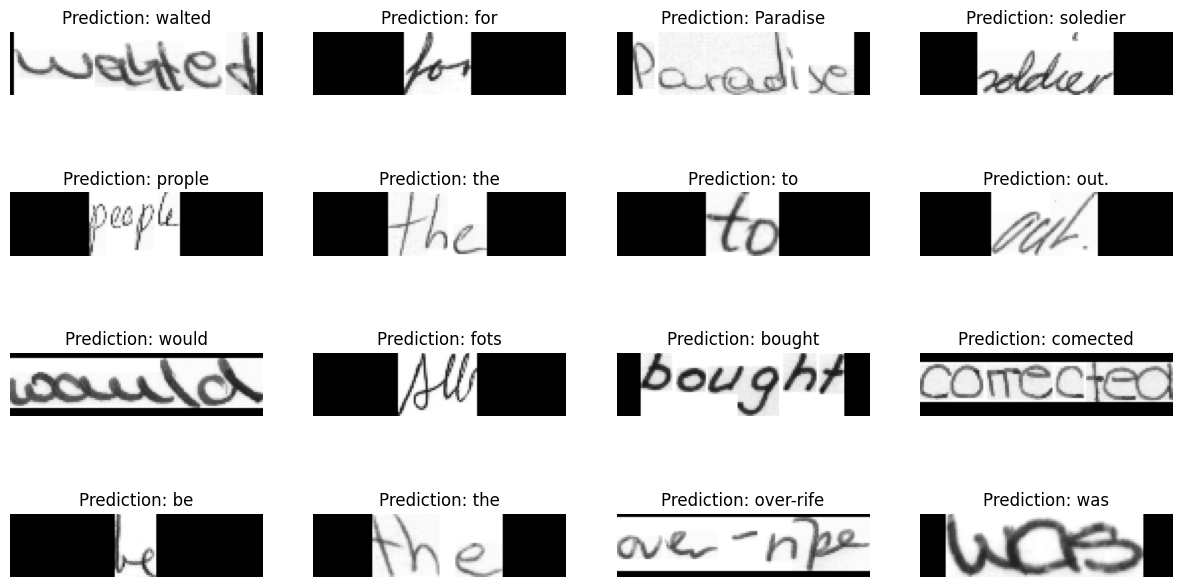

In [ ]:
def decode_batch_predictions(pred):
    """
      This function takes as argument the model's predictions which aren't
      elligible and decodes this and returns a list of words.
    """
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][
        :, :max_len
    ]
    # Iterate over the results and gets back the text.
    # Each word is appended to the output_text list which is returned
    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    return output_text

# We now check our inferencing on the test data
for batch in test_ds.take(1):
    batch_images = batch["image"]
    # Creates our matplotlib figure, 4x4 grid here
    _, ax = plt.subplots(4, 4, figsize=(15, 8))

    # For inferencing we pass our images as argument into .predict() and decode to get text
    preds = epoch100_model.predict(batch_images)
    pred_texts = decode_batch_predictions(preds)

    # We only iterate through the first 16 images/words
    for i in range(16):
        img = batch_images[i]
        # We need to reverse the image processing done earlier
        img = tf.image.flip_left_right(img)
        img = tf.transpose(img, perm=[1, 0, 2])
        img = (img * 255.0).numpy().clip(0, 255).astype(np.uint8)
        img = img[:, :, 0]

        title = f"Prediction: {pred_texts[i]}"A
        ax[i // 4, i % 4].imshow(img, cmap="gray")
        ax[i // 4, i % 4].set_title(title)
        ax[i // 4, i % 4].axis("off")

plt.show()